# Imports

- Notebook about polarization and how uncertainty guide behavior
- Making agent others type of behavior (check the poll, talk with neihborg and this make it change the preference)
- Disatisfaction metrics

In [1]:
%load_ext autoreload
%autoreload 2
import time

import jax
import matplotlib.pyplot as plt

from eci.adapter import SimulationAdapter
from eci.environment import Environment
from eci.visualizer import SimulationVisualizer
from eci.voting_system.plurality import _vote_plurality
from eci.voting_system.quadratic import _vote_quadratic

## Analyze polarization
Add a metric to measure group polarization over time. Do voters eventually agree (consensus) or do they divide into opposing camps?

## Agent behavior:

Instead of purely random voting, you could code "strategic" agents that change their vote based on polls or the opinions of their neighbors in the network

# Collective decision making under differents voting systems.
- Plurality & Quadratic voting
- Measure disatifaction
- Under different preferences (higt/low uncertainty)

# Parameters

In [2]:
NUM_VOTERS = 50
NUM_CANDIDATES = 4
NUM_PREFERENCES = 2
NUM_SIMULATIONS = 100  # the node trajectories

# Environement

In [3]:
env = Environment(
    num_voters=NUM_VOTERS,
    num_candidates=NUM_CANDIDATES,
    num_preferences=NUM_PREFERENCES,
)
env.num_simulations = NUM_SIMULATIONS

# Changing preferences of two groups

We can access parameters of the preference distribution and modify them using:

In [4]:
env.voters[0].preferences  # access agent 0
env.voters[0].preferences["mean"][0]  # access mean of preference 0
env.voters[0].preferences["precision"][0]  # access precision of preference 0

Array(0.74241656, dtype=float32)

We can plot the current distribution of candidate et voters preferences

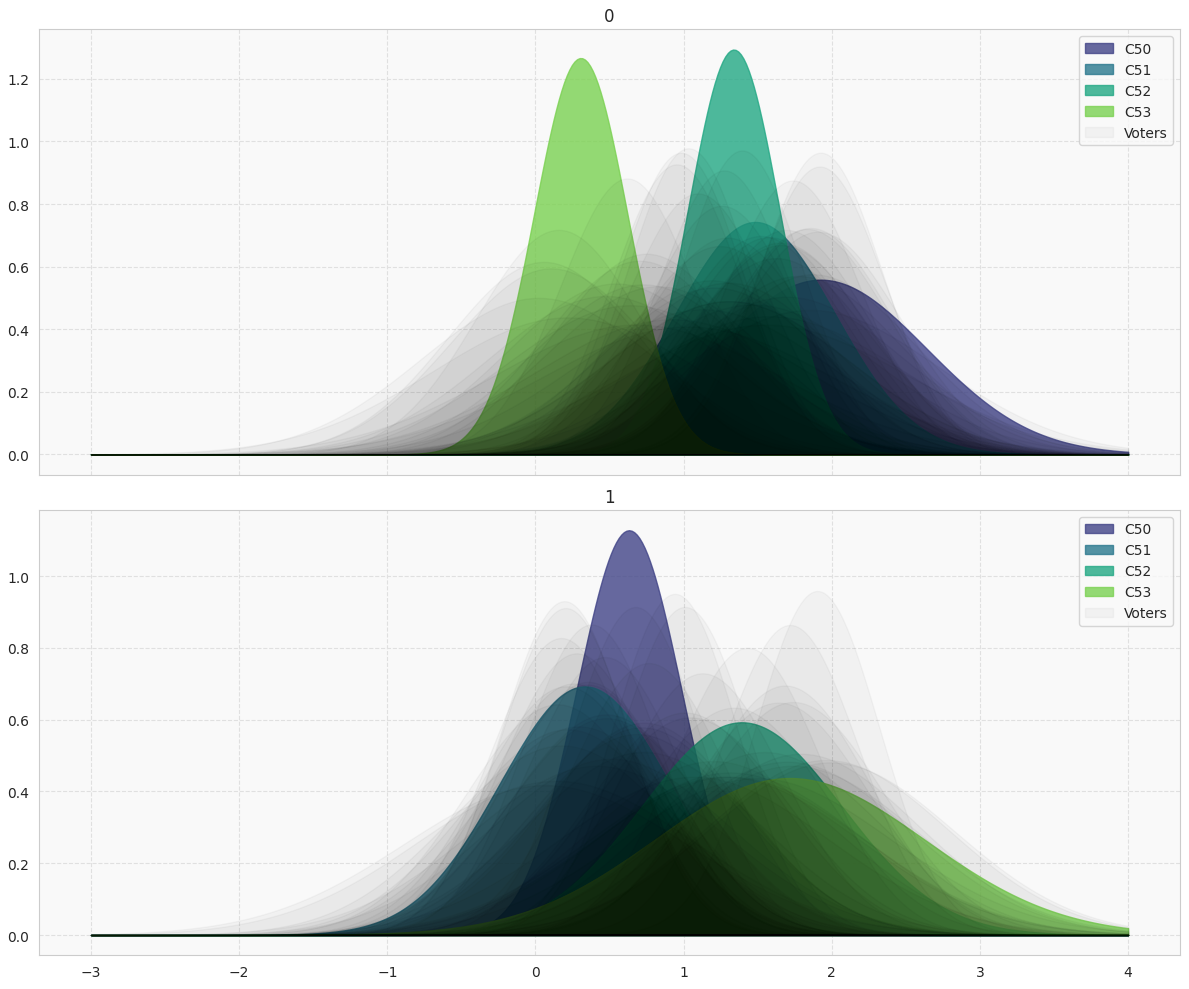

In [5]:
# 1. Initialisation viz and adapter
viz = SimulationVisualizer()
adapter = SimulationAdapter()
pref_data = adapter.prepare_preference_data(env)
fig, ax1 = viz.plot_preference_distributions(pref_data)

Then we can change the distribution of voters

In [6]:
env.voters[0].preferences["mean"][0]
env.voters[0].preferences["mean"] = env.voters[0].preferences["mean"].at[1].set(-1)
env.voters[0].preferences["mean"][1]

Array(-1., dtype=float32)

In [7]:
ID_THRESHOLD = 25

for voter in env.voters:
    if voter.id > ID_THRESHOLD:
        # This loop sets *every* preference index for this voter
        for preference_ixd in range(NUM_PREFERENCES):
            voter.preferences["mean"] = (
                voter.preferences["mean"].at[preference_ixd].set(3.0)
            )
            voter.preferences["precision"] = (
                voter.preferences["precision"].at[preference_ixd].set(1.5)
            )
    else:
        for preference_ixd in range(NUM_PREFERENCES):
            voter.preferences["mean"] = (
                voter.preferences["mean"].at[preference_ixd].set(-3.0)
            )
            voter.preferences["precision"] = (
                voter.preferences["precision"].at[preference_ixd].set(1.3)
            )

In [8]:
# Do the same for candidates
env.candidates[0].policy["mean"] = (
    env.candidates[0].policy["mean"].at[0].set(2.0).at[1].set(2.0)
)
env.candidates[0].policy["precision"] = (
    env.candidates[0].policy["precision"].at[0].set(1.0).at[1].set(1.0)
)

In [9]:
# Do the same for candidates
env.candidates[1].policy["mean"] = (
    env.candidates[1].policy["mean"].at[0].set(-2.0).at[1].set(-2.0)
)
env.candidates[1].policy["precision"] = (
    env.candidates[1].policy["precision"].at[0].set(1.0).at[1].set(1.0)
)

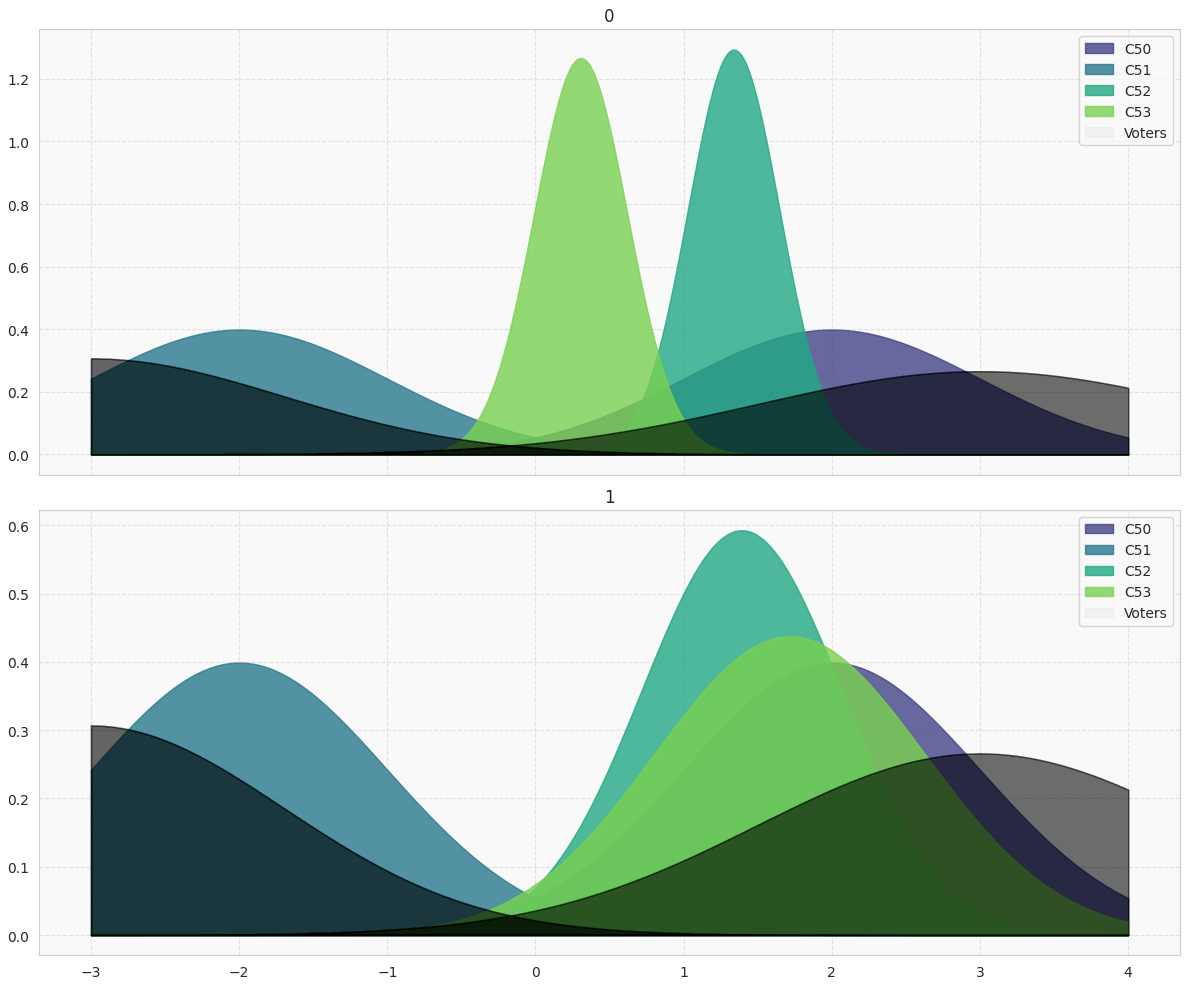

In [10]:
# 1. Initialisation viz and adapter
pref_data = adapter.prepare_preference_data(env)
fig, ax1 = viz.plot_preference_distributions(pref_data)

In [11]:
# Then we run the agent networks
env.initialize_network()

# Run simulation

In [12]:
# intiatialize random key
key = jax.random.PRNGKey(int(time.time()))
# run n simulations
sim = env.run_n_simulation(_vote_plurality, key, NUM_SIMULATIONS)
# update the agents with the results
env._update_agents()

In [13]:
# use result to create dataframe for plotting
env.df = env.create_data_frame()

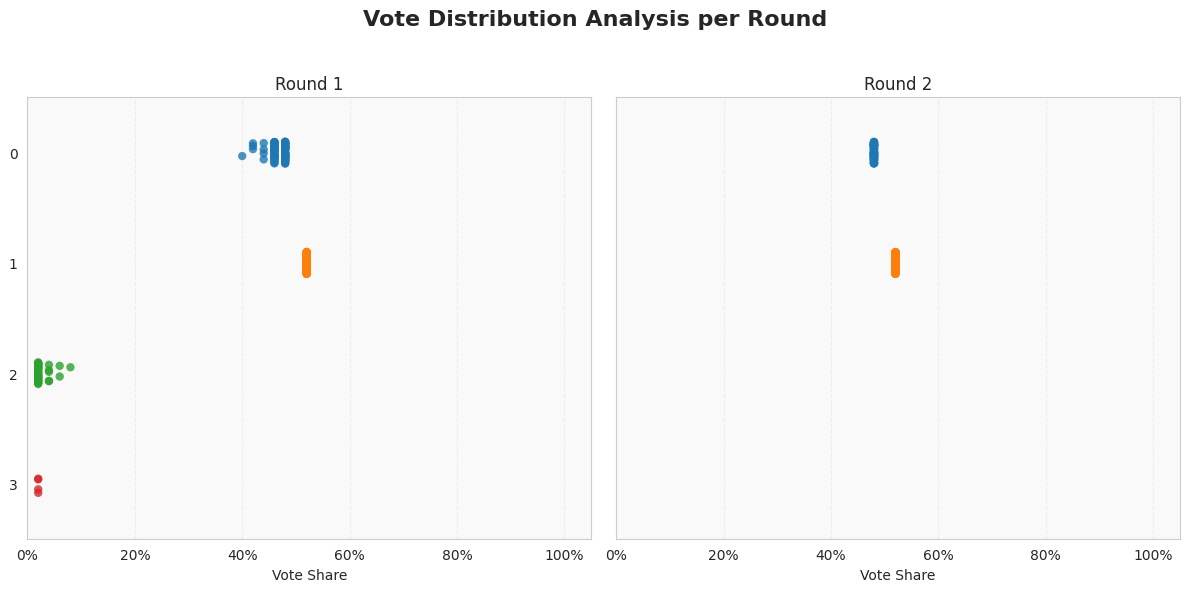

In [14]:
votes_data = adapter.extract_vote_counts(env.df)
fig, axes = viz.plot_vote_proportions(votes_data, plot_kind="stripplot")
plt.show()

In [15]:
# intiatialize random key
key = jax.random.PRNGKey(int(time.time()))
# run n simulations
sim = env.run_n_simulation(_vote_quadratic, key, NUM_SIMULATIONS)
# update the agents with the results
env._update_agents()

In [16]:
# use result to create dataframe for plotting
env.df = env.create_data_frame()

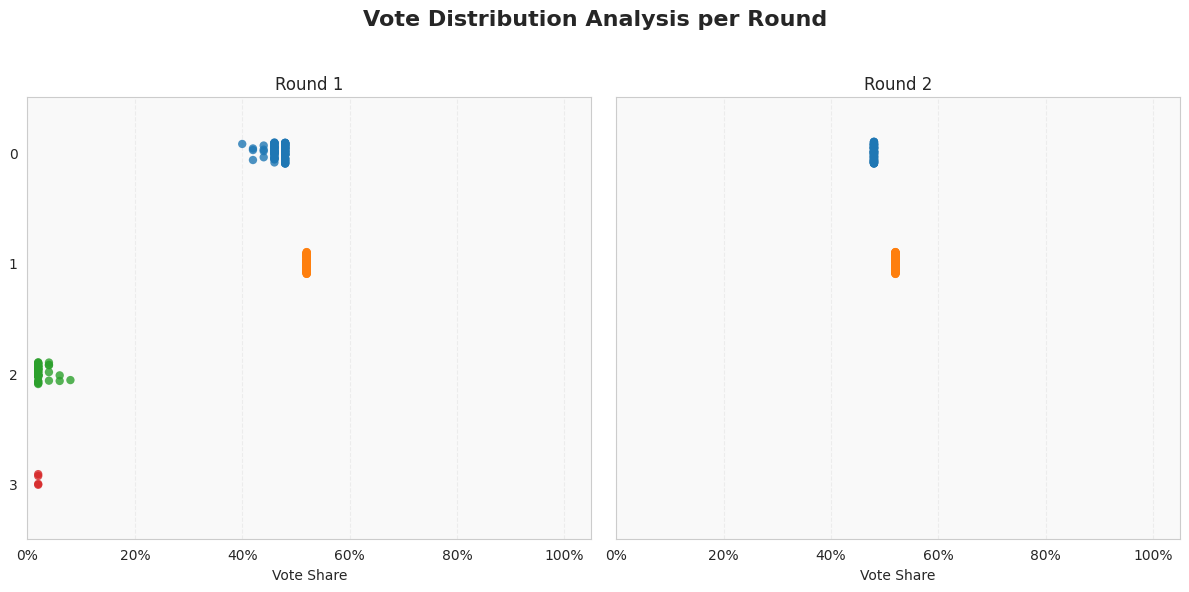

In [17]:
votes_data = adapter.extract_vote_counts(env.df)
fig, axes = viz.plot_vote_proportions(votes_data, plot_kind="stripplot")
plt.show()